# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-09-02 21:39:58.452369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788385198.701887      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788385198.773598      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788385199.395796      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788385199.395847      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788385199.395850      23 computation_placer.cc:177] computation placer alr

In [2]:
pd.set_option('display.max_columns', None)          # Show all columns
pd.set_option('display.width', None)                # Adjust width dynamically
pd.set_option('display.expand_frame_repr', False)   # Prevent column wrapping
warnings.filterwarnings('ignore')                   # Ignores all warnings

# Load Data & Convert to DF

In [3]:
data_dir = Path('/kaggle/input/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]')

# Get all image paths (assuming .jpg or .png)

filepaths = list(data_dir.glob(r'**/*.png')) + list(data_dir.glob(r'**/*.jpg'))

# Create the DataFrame
df = pd.DataFrame({
    'Filepath': [str(f) for f in filepaths],
    'Label': [f.parent.name for f in filepaths]
})

# Shuffle the data
df = df.sample(frac=1).reset_index(drop=True)
print(df.head())

                                            Filepath              Label
0  /kaggle/input/datasets/mohammadamireshraghi/bl...             Benign
1  /kaggle/input/datasets/mohammadamireshraghi/bl...  [Malignant] Pre-B
2  /kaggle/input/datasets/mohammadamireshraghi/bl...  [Malignant] Pre-B
3  /kaggle/input/datasets/mohammadamireshraghi/bl...  [Malignant] Pro-B
4  /kaggle/input/datasets/mohammadamireshraghi/bl...  [Malignant] Pre-B


In [4]:
df

,Filepath,Label
0,/kaggle/input/datasets/mohammadamireshraghi/bl...,Benign
1,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pre-B
2,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pre-B
3,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pro-B
4,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pre-B
...,...,...
3237,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pre-B
3238,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pro-B
3239,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] early Pre-B
3240,/kaggle/input/datasets/mohammadamireshraghi/bl...,[Malignant] Pro-B


In [5]:
df.shape

(3242, 2)

In [6]:
df['Label'].value_counts()

Label
[Malignant] early Pre-B    979
[Malignant] Pre-B          955
[Malignant] Pro-B          796
Benign                     512
Name: count, dtype: int64

# Data Preprocessing

In [7]:
# 1 Split Data
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)


# 2 Setup Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)
test_gen = ImageDataGenerator(rescale=1./255)

# 3 Create the Data Streams
train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

test_data = test_gen.flow_from_dataframe(
    test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False 
)

# 4. Check Count
print("Test set counts:")
print(test_df['Label'].value_counts())

Found 2593 validated image filenames belonging to 4 classes.
Found 649 validated image filenames belonging to 4 classes.
Test set counts:
Label
[Malignant] early Pre-B    196
[Malignant] Pre-B          191
[Malignant] Pro-B          159
Benign                     103
Name: count, dtype: int64


### Random Image from Data

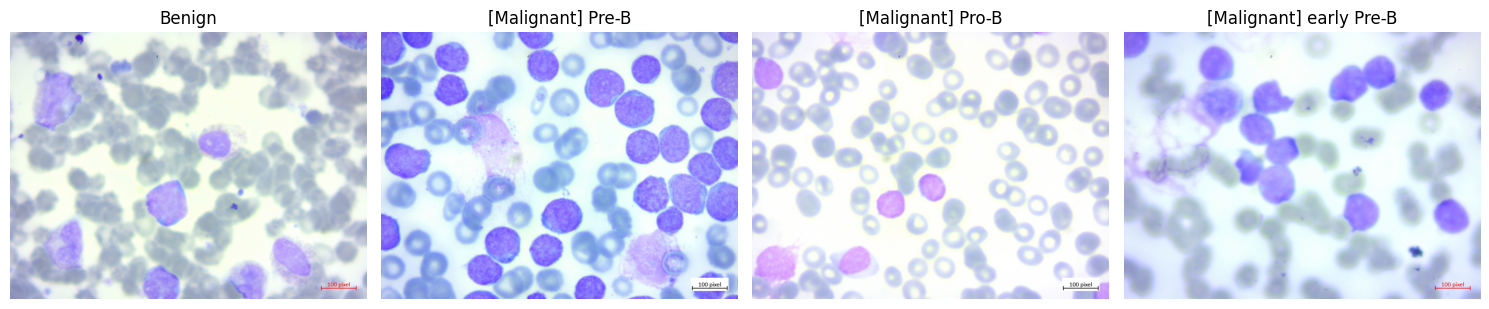

In [8]:
import matplotlib.pyplot as plt
import cv2

# 4 unique classes
classes = df['Label'].unique()

plt.figure(figsize=(15, 5))

for i, label in enumerate(classes):
    # Filter the df for the specific class and pick 1 random
    sample = df[df['Label'] == label].sample(1)
    img_path = sample['Filepath'].iloc[0]

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR to RGB

    # Plot
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

# CNN Model Architecture 

In [9]:
model = models.Sequential([
    # 1st Block: Low-level features (Edges/Colors)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    # layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    # 2nd Block: Mid-level features (Textures)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),

    # 3rd Block: High-level features (Cell shape/Nucleus details)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.4),

    # 4th Block: Deep semantic features
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.5),

    # Improved Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    # layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax') # 4 classes of blood cells/cancer
])

I0000 00:00:1788385238.185260      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788385238.191413      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,412 (1.91 MB)

 Trainable params: 501,412 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

# Model Training

In [13]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=100
)

Epoch 1/100


I0000 00:00:1788385246.304078      76 service.cc:152] XLA service 0x796f69394b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788385246.304143      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1788385246.304150      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1788385246.959567      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-09-02 21:40:51.714977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:40:51.868899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:40:54.599380: E external/local_xl

 1/82 ━━━━━━━━━━━━━━━━━━━━ 28:59 21s/step - accuracy: 0.2812 - loss: 1.3767

I0000 00:00:1788385263.757968      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/82 ━━━━━━━━━━━━━━━━━━━━ 43s 997ms/step - accuracy: 0.2992 - loss: 1.3821

2026-09-02 21:41:42.575442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:41:42.715820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:41:42.945148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:41:43.080927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-02 21:41:43.631533: E external/local_xla/xla/stream_

82/82 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.3009 - loss: 1.3758 - val_accuracy: 0.2943 - val_loss: 1.3263
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 67s 812ms/step - accuracy: 0.5843 - loss: 1.0049 - val_accuracy: 0.7781 - val_loss: 0.5809
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 66s 808ms/step - accuracy: 0.7919 - loss: 0.5457 - val_accuracy: 0.7966 - val_loss: 0.4750
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 66s 808ms/step - accuracy: 0.7939 - loss: 0.4935 - val_accuracy: 0.7858 - val_loss: 0.5008
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 796ms/step - accuracy: 0.8296 - loss: 0.4575 - val_accuracy: 0.8690 - val_loss: 0.3709
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 792ms/step - accuracy: 0.8745 - loss: 0.3534 - val_accuracy: 0.8783 - val_loss: 0.3344
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 785ms/step - accuracy: 0.8618 - loss: 0.3650 - val_accuracy: 0.8536 - val_loss: 0.3959
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 790ms/step - accuracy: 0.8852 - loss: 0.3137 - val_accuracy: 

In [14]:
history2 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 885ms/step - accuracy: 0.9820 - loss: 0.0478 - val_accuracy: 0.9815 - val_loss: 0.0424
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 72s 872ms/step - accuracy: 0.9864 - loss: 0.0370 - val_accuracy: 0.9923 - val_loss: 0.0228
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 72s 878ms/step - accuracy: 0.9903 - loss: 0.0280 - val_accuracy: 0.9908 - val_loss: 0.0281
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 860ms/step - accuracy: 0.9914 - loss: 0.0317 - val_accuracy: 0.9938 - val_loss: 0.0198
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 72s 875ms/step - accuracy: 0.9825 - loss: 0.0583 - val_accuracy: 0.9522 - val_loss: 0.1009
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 861ms/step - accuracy: 0.9736 - loss: 0.0780 - val_accuracy: 0.9846 - val_loss: 0.0339
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 71s 868ms/step - accuracy: 0.9828 - loss: 0.0483 - val_accuracy: 0.9846 - val_loss: 0.0418
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 839ms/step - accuracy: 0.9763 - loss: 0.0728 - 

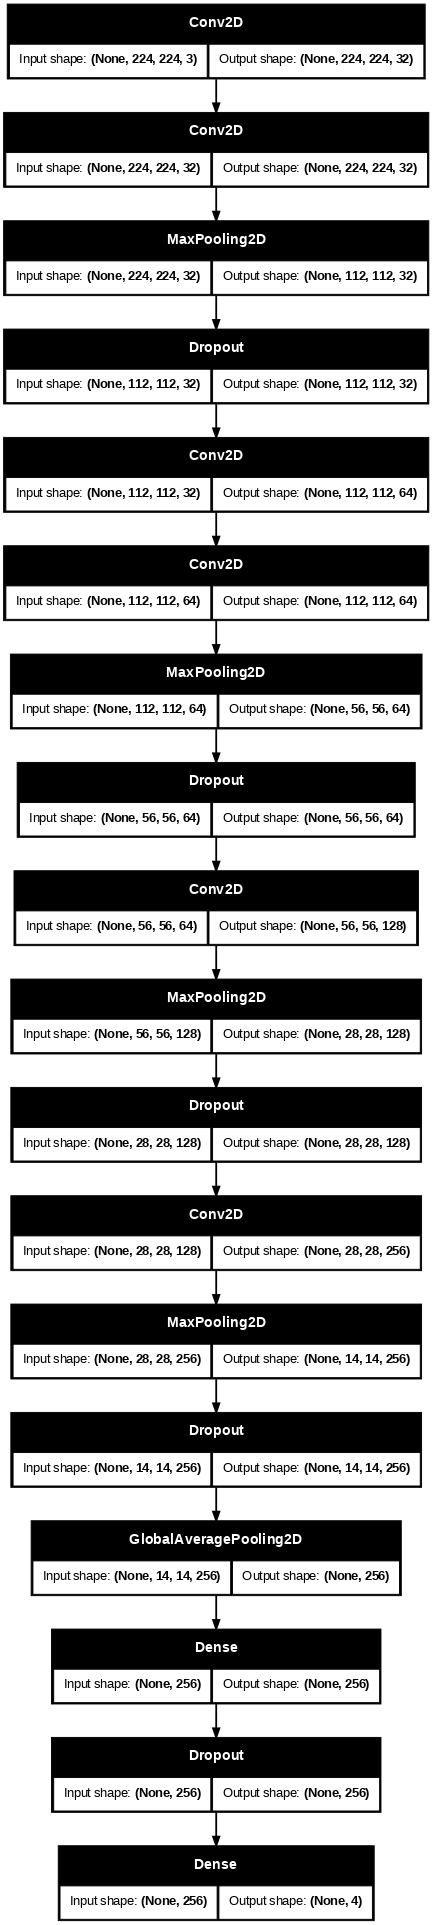

In [15]:
from keras.utils import plot_model

plot_model(
    model,
    to_file='model_plot_compact.png',
    show_shapes=True,
    show_layer_names=False, # Hide names
    # rankdir='LR',           # Horizontal layout
    dpi=65                  # Smaller scale
)

# Model Accuracy & Evalutaion

In [16]:
model.evaluate(test_data, verbose=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 395ms/step - accuracy: 0.9880 - loss: 0.0222


[0.013398274779319763, 0.9938367009162903]

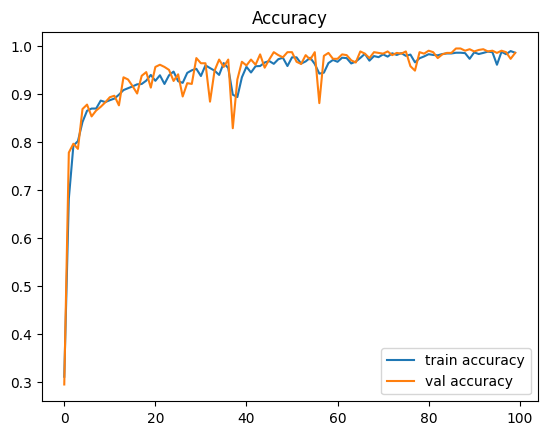

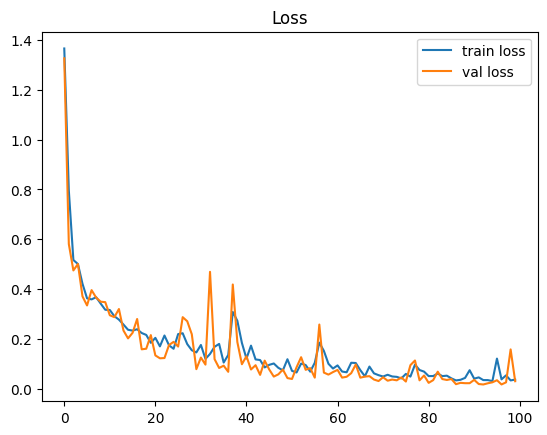

In [17]:
# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step


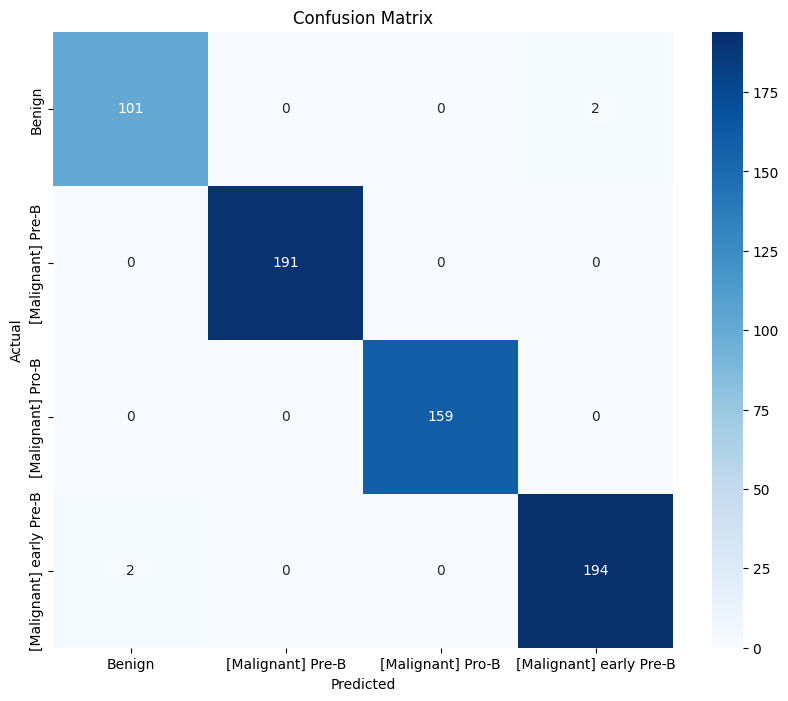

                         precision    recall  f1-score   support

                 Benign       0.98      0.98      0.98       103
      [Malignant] Pre-B       1.00      1.00      1.00       191
      [Malignant] Pro-B       1.00      1.00      1.00       159
[Malignant] early Pre-B       0.99      0.99      0.99       196

               accuracy                           0.99       649
              macro avg       0.99      0.99      0.99       649
           weighted avg       0.99      0.99      0.99       649



In [18]:
test_data.reset() # Reset generator to start of set
preds = model.predict(test_data)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Plot Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(true_classes, pred_classes, target_names=class_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step


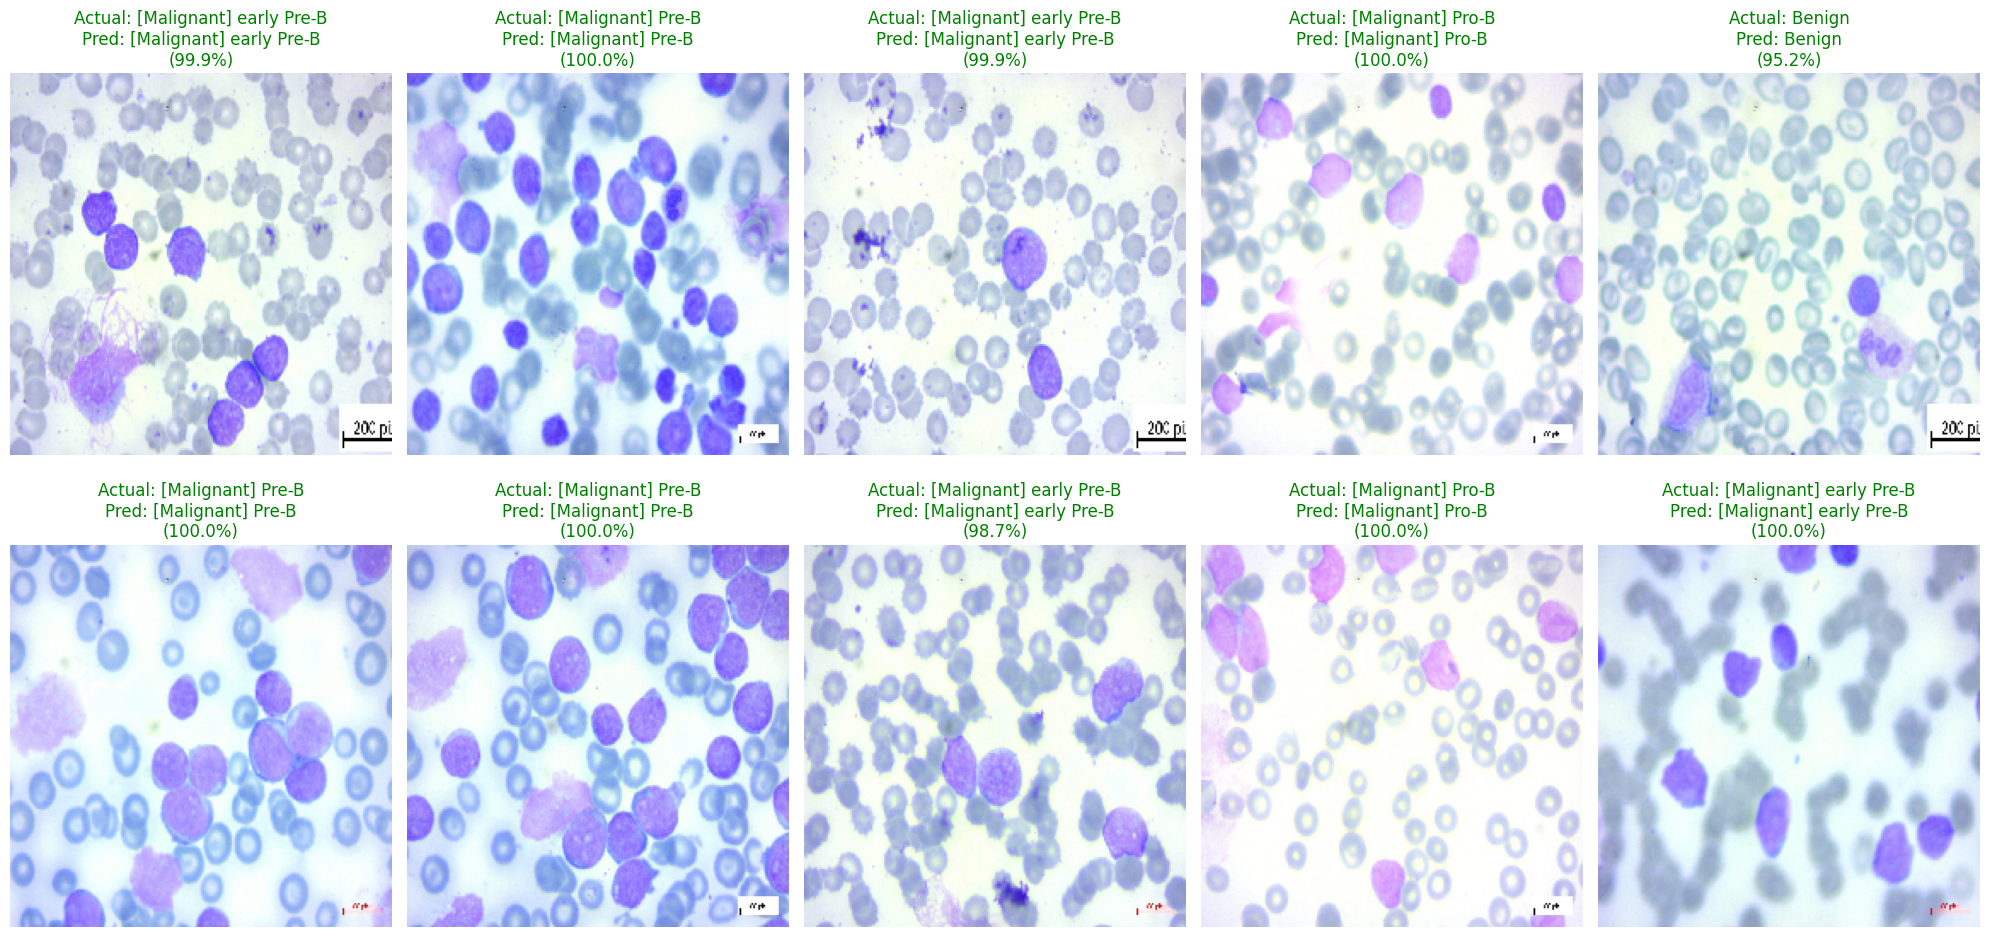

In [19]:
def plot_actual_vs_predicted(generator, model, num_images=10):
    images, labels = next(generator)
    preds = model.predict(images)
    
    # Get class labels from generator
    class_labels = list(generator.class_indices.keys())
    
    plt.figure(figsize=(20, 10))
    for i in range(min(num_images, len(images))):
        plt.subplot(2, 5, i + 1)
        
        # Check if image has 3 channels or 1
        display_img = images[i]
        if display_img.shape[-1] == 1: # It's Grayscale
            plt.imshow(display_img.reshape(224, 224), cmap='gray')
        else: # It's RGB
            plt.imshow(display_img)
        
        actual = class_labels[np.argmax(labels[i])]
        predicted = class_labels[np.argmax(preds[i])]
        confidence = np.max(preds[i]) * 100
        
        color = 'green' if actual == predicted else 'red'
        plt.title(f"Actual: {actual}\nPred: {predicted}\n({confidence:.1f}%)", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(test_data, model)

### Function to try the model

In [20]:
import cv2

def predict_single_image(img_path, model):
    # 1. Load and convert to grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    # 2. Resize
    img = cv2.resize(img, (224, 224))
    # 3. Scale pixels
    img = img / 255.0
    # 4. Reshape for model (Batch, H, W, Channel) -> (1, 224, 224, 1)
    img = np.expand_dims(img, axis=(0, -1))
    
    prediction = model.predict(img)
    result_idx = np.argmax(prediction)
    return class_labels[result_idx], np.max(prediction)

In [21]:
model.save("Blood_Cell.h5")